## **1. Introducción**

El presente informe tiene como objetivo analizar un conjunto de datos meteorológicos de distintas ubicaciones de Australia, utilizando la metodología CRISP-DM como marco para apoyar la toma de decisiones basada en datos. El análisis se enfoca en las fases de Business Understanding y Data Understanding.
El dataset contiene observaciones diarias de variables climáticas como temperatura, humedad, presión atmosférica, viento y precipitaciones, además de la variable objetivo RainTomorrow, que indica la ocurrencia de lluvia al día siguiente. El propósito del análisis es identificar patrones relevantes que permitan comprender los factores asociados a la precipitación y servir como base para etapas posteriores como la preparación de datos y el modelamiento.


## 2.1 Identificación del Problema

Australia presenta una alta variabilidad climática debido a su extensa superficie y diversidad geográfica, lo que dificulta la predicción precisa de fenómenos meteorológicos como la lluvia. Esta situación impacta directamente en sectores como la agricultura, el transporte y la gestión de riesgos climáticos.

El problema principal consiste en identificar los factores climáticos que influyen en la ocurrencia de lluvia al día siguiente, representada por la variable **RainTomorrow**, con el fin de mejorar la capacidad de predicción y apoyar la toma de decisiones informadas.
``


### 2.2 Objetivos Clave

**Objetivo general:**
Analizar el dataset meteorológico para identificar patrones y relaciones entre variables que permitan comprender la ocurrencia de lluvia.

**Objetivos específicos:**
- Analizar las principales variables climáticas del dataset
- Identificar relaciones entre variables meteorológicas
- Detectar valores atípicos y datos faltantes
- Evaluar la influencia de distintas variables en la ocurrencia de lluvia

#
# 2.2 Objetivos Clave y KPIs

**Objetivo general:**  
Analizar las variables meteorológicas del dataset para identificar patrones asociados a la ocurrencia de lluvia al día siguiente.

**Objetivos específicos:**  
- Analizar el comportamiento de las principales variables climáticas  
- Identificar relaciones entre variables meteorológicas  
- Detectar valores atípicos y datos faltantes  
- Evaluar su influencia sobre la variable *RainTomorrow*  

**KPIs propuestos:**  
- Probabilidad de ocurrencia de lluvia al día siguiente (*RainTomorrow*)  
- Relación entre variables clave (humedad, presión, precipitación) y la lluvia  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

df = pd.read_csv("weatherAUS.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'weatherAUS.csv'

In [ ]:
df.shape

NameError: name 'df' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

El dataset está compuesto por variables numéricas y categóricas.

Las variables numéricas corresponden a mediciones climáticas como temperatura, humedad, presión y velocidad del viento. Por otro lado, las variables categóricas incluyen la ubicación geográfica y la dirección del viento.

Esta combinación permite realizar análisis descriptivos, correlacionales y exploratorios.

In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


A partir de la estadística descriptiva se observa una alta variabilidad en variables como la precipitación, la temperatura y la humedad.

Por ejemplo, la variable de precipitación presenta valores mínimos cercanos a cero y máximos considerablemente altos, lo que evidencia la ocurrencia de eventos climáticos extremos.

Esto refleja la diversidad climática presente en Australia.

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013


Se identifican valores faltantes en diversas variables, especialmente en aquellas relacionadas con evaporación, horas de sol y dirección del viento.

La presencia de estos valores puede afectar el análisis, por lo que es necesario aplicar técnicas de limpieza o tratamiento de datos.

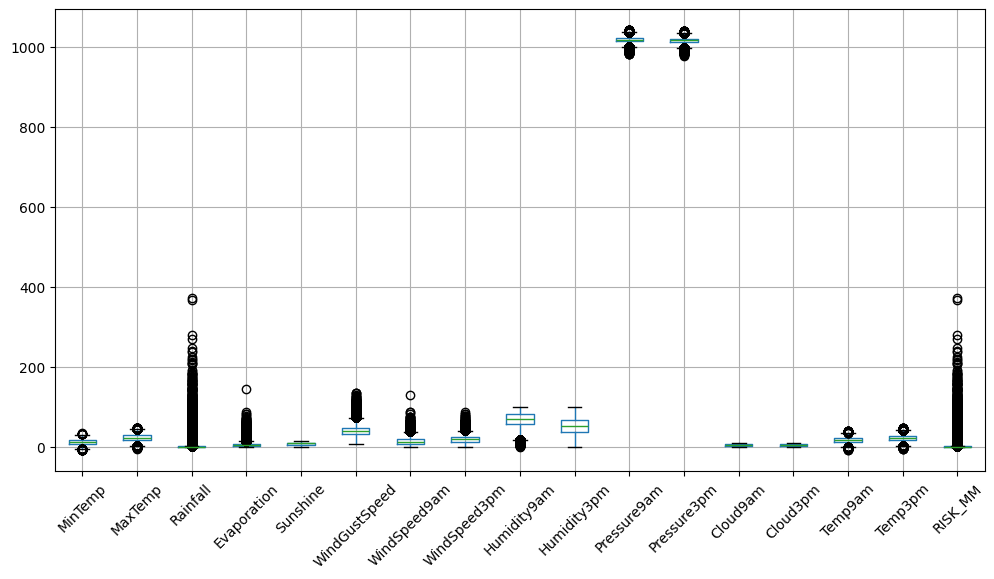

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

El análisis mediante diagramas de caja permite identificar la presencia de valores atípicos en variables como precipitación, velocidad del viento y presión atmosférica.

Estos valores extremos pueden corresponder a eventos climáticos inusuales, como tormentas o condiciones extremas.

In [4]:
df = df.dropna()

NameError: name 'df' is not defined

Se eliminan los registros con valores faltantes con el fin de trabajar con un dataset consistente y evitar distorsiones en el análisis.

Sin embargo, en futuras etapas se recomienda aplicar técnicas de imputación para conservar mayor cantidad de información.

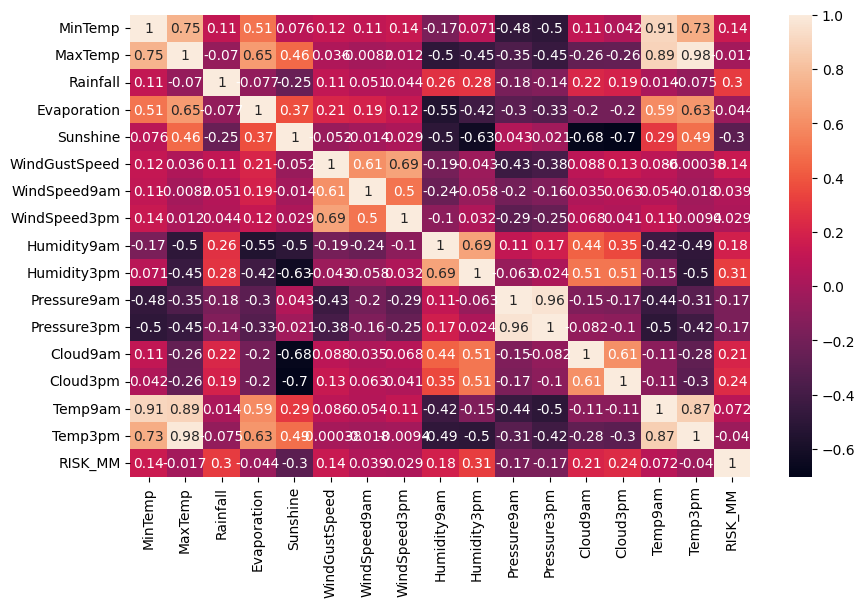

In [ ]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

El análisis de correlación permite identificar relaciones significativas entre variables.

Se observa que la humedad presenta una relación positiva con la ocurrencia de lluvia, mientras que la presión atmosférica tiende a presentar una relación inversa.

Estas relaciones son fundamentales para comprender los factores que influyen en la variable objetivo.

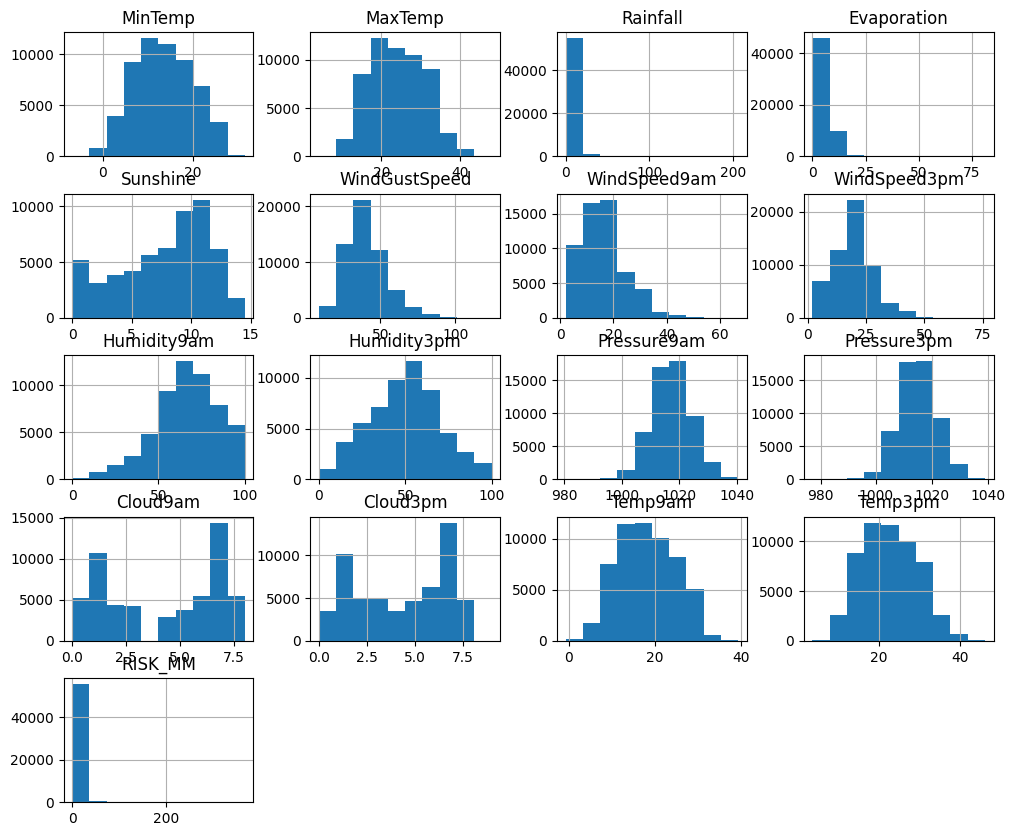

In [ ]:
df.hist(figsize=(12,10))
plt.show()

Los histogramas permiten visualizar la distribución de las variables.

Se observa que muchas variables no siguen una distribución normal, lo que indica la presencia de sesgos y variabilidad en los datos, característicos de fenómenos climáticos.

## 4. Insights Relevantes

1. Se observa que la humedad relativa, especialmente en la tarde (Hum3pm), presenta una fuerte relación con la ocurrencia de lluvia, lo que indica que niveles elevados de humedad aumentan significativamente la probabilidad de precipitaciones.

2. La variable Rainfall (precipitación actual) muestra una relación directa con RainTomorrow, sugiriendo que los días lluviosos tienden a ser seguidos por condiciones similares.

3. Se identifican valores atípicos en variables como velocidad del viento y precipitación, lo que refleja la presencia de eventos climáticos extremos.

4. La presión atmosférica presenta una relación inversa con la lluvia, lo que indica que presiones más bajas están asociadas a condiciones meteorológicas inestables.

5. La variabilidad en temperaturas y humedad evidencia la diversidad climática del territorio australiano, lo que influye en la complejidad de la predicción.

## 5. Propuesta de Pasos a Seguir

- Implementar modelos de machine learning para predecir la variable RainTomorrow
- Aplicar técnicas de imputación para tratar valores faltantes
- Analizar en mayor profundidad variables categóricas como la dirección del viento
- Evaluar algoritmos de clasificación como árboles de decisión o regresión logística

## 6. Conclusiones Generales

El análisis exploratorio permitió comprender la estructura del dataset y detectar patrones relevantes en el comportamiento climático.

Se identificaron variables clave como la humedad, la precipitación y la presión atmosférica como factores determinantes en la ocurrencia de lluvia.

Los resultados obtenidos permiten avanzar hacia etapas más avanzadas del proceso de minería de datos, particularmente en la construcción de modelos predictivos que apoyen la toma de decisiones.